# Airbnb Supervised Learning - Regression Analysis
Airbnb Open Data

In [85]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (8, 4)

def to_numeric_currency(series):
    return pd.to_numeric(series.astype(str).str.replace(r'[$, ]', '', regex=True), errors='coerce')

base_dir = Path.cwd()
data_path = base_dir / 'Airbnb_Open_Data.csv'
print('Data file:', data_path)

Data file: c:\Users\LOQ\Desktop\master\machine_learning\data_cleaning\airbnb_example\mywork\Airbnb_Open_Data.csv


## 1. Load Data

In [86]:
# Load dataset
data = pd.read_csv(data_path, low_memory=False)

if 'price' in data.columns:
    data['price_num'] = to_numeric_currency(data['price'])
if 'service fee' in data.columns:
    data['service_fee_num'] = to_numeric_currency(data['service fee'])

print(f'Shape: {data.shape}')
print(f'Columns: {data.columns.tolist()}')
print(f'\nFirst 5 rows:\n{data.head()}')

Shape: (102599, 28)
Columns: ['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license', 'price_num', 'service_fee_num']

First 5 rows:
        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name n

## 2. Data Quality Check

In [87]:
# Check for missing values and duplicates
print('Missing values:')
print(data.isna().sum().sort_values(ascending=False).head(15))
print(f'\nDuplicates: {data.duplicated().sum()}')

stats_cols = [col for col in ['price_num', 'service_fee_num', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365'] if col in data.columns]
if stats_cols:
    print(f'\nBasic statistics:\n{data[stats_cols].describe()}')

Missing values:
license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service_fee_num                      273
service fee                          273
NAME                                 250
price                                247
dtype: int64

Duplicates: 541

Basic statistics:
           price_num  service_fee_num  minimum nights  number of reviews  \
count  102352.000000    102326.000000   102190.000000      102416.000000   
mean      625.293536       125.026924        8.135845          27.483743   
std       331.671614        66.325739       30.553781          49.508954   
min        50.00

## 3. Visualize Before Cleaning

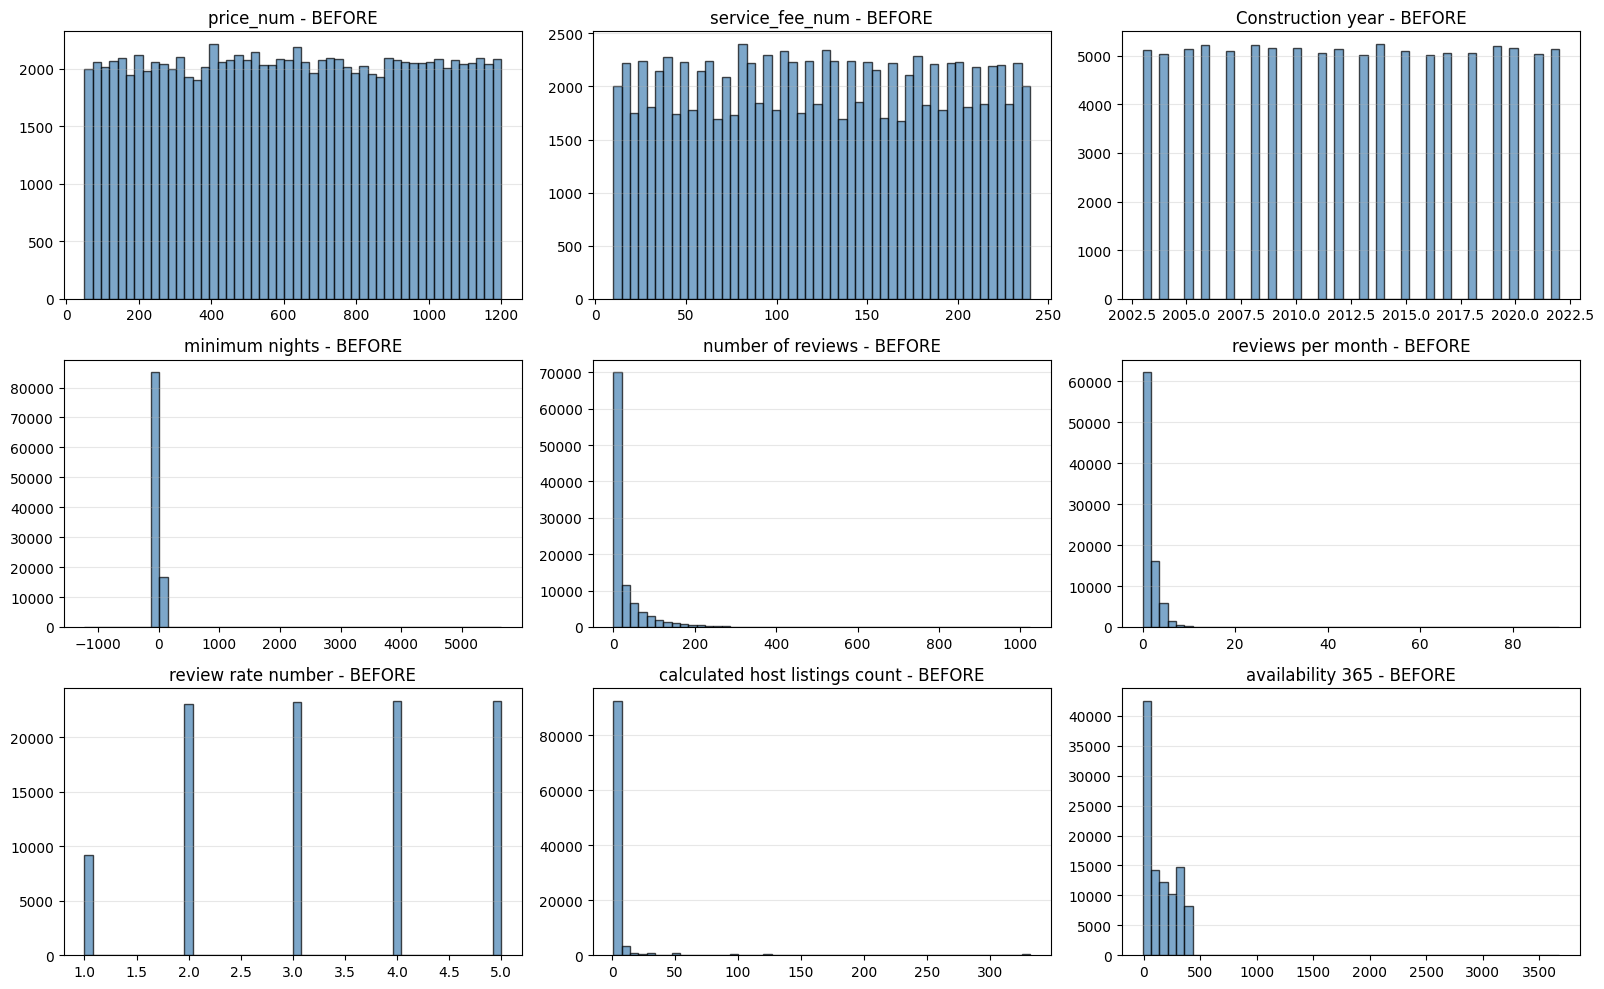

In [68]:
# Histograms before cleaning
cols = [c for c in ['price_num', 'service_fee_num', 'Construction year', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365'] if c in data.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].hist(data[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} - BEFORE')
    axes[i].grid(axis='y', alpha=0.3)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

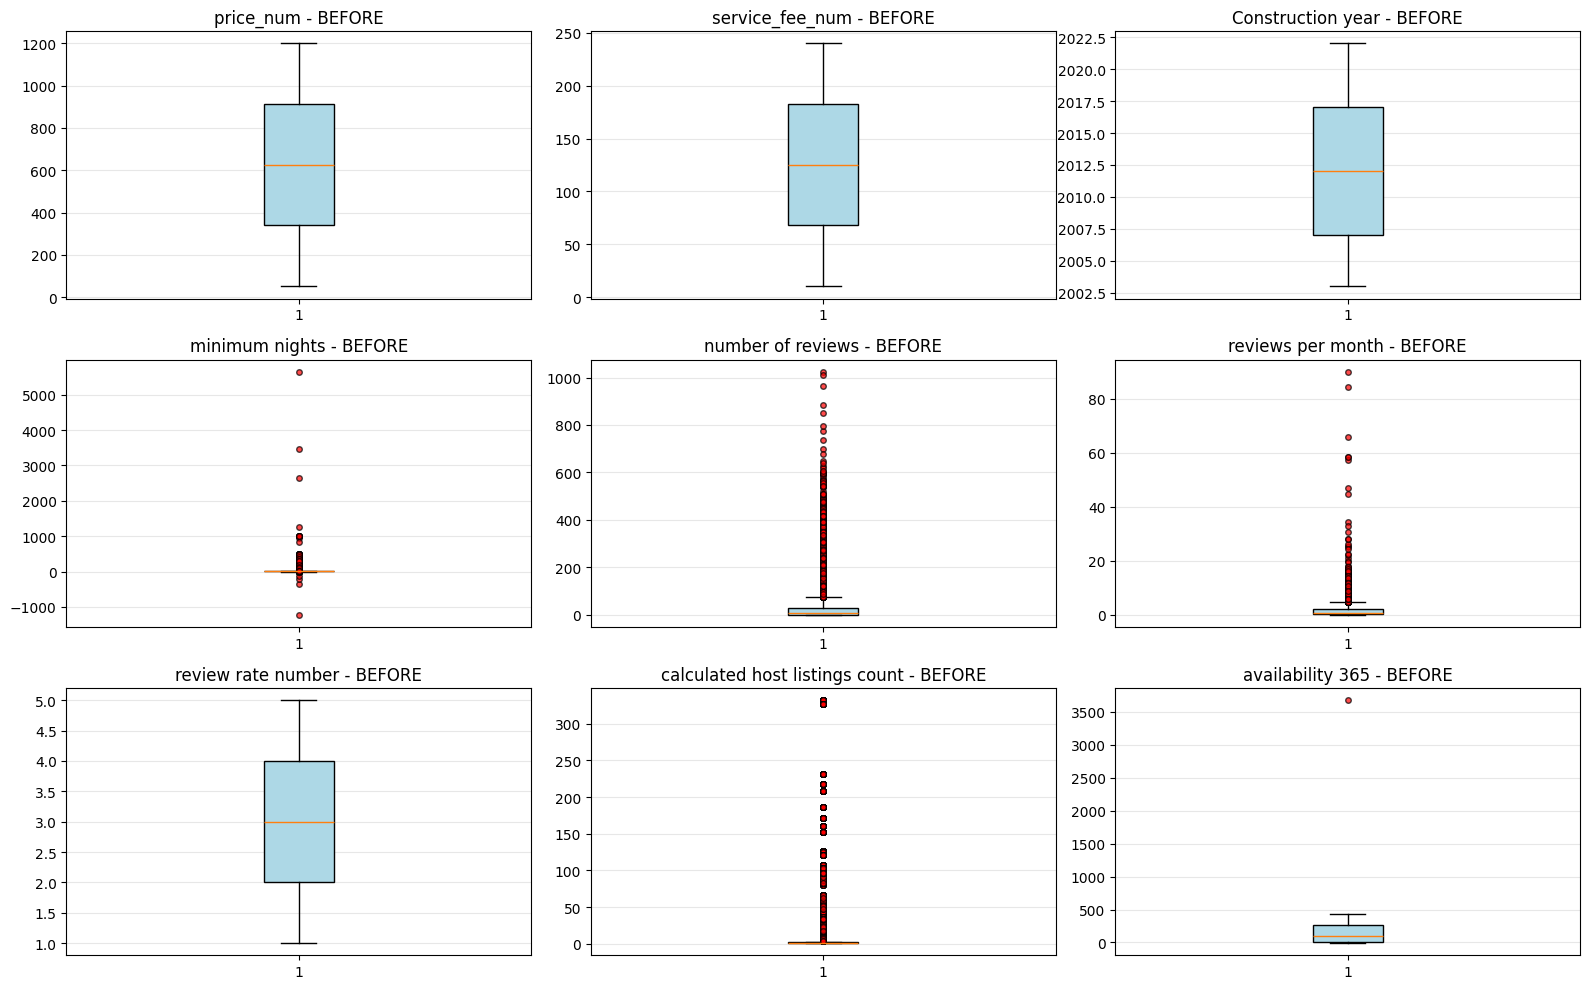

In [69]:
# Box plots before cleaning
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.7))
    axes[i].set_title(f'{col} - BEFORE')
    axes[i].grid(axis='y', alpha=0.3)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [103]:
# Step 1: Remove duplicates and keep a working copy
rows_before_cleaning = len(data)
data_clean = data.drop_duplicates().copy().reset_index(drop=True)
rows_removed_duplicates = rows_before_cleaning - len(data_clean)
print(f'Duplicates removed: {rows_removed_duplicates} rows')

# Step 2: Drop sparse or text columns that do not help the regression
columns_to_drop = [col for col in ['id', 'host id', 'NAME', 'name', 'host name', 'house_rules', 'license', 'last review'] if col in data_clean.columns]
data_clean = data_clean.drop(columns=columns_to_drop)
print('Dropped columns:', columns_to_drop)

# Step 3: Clean numeric columns and categorical columns
if 'price_num' in data_clean.columns:
    data_clean = data_clean.dropna(subset=['price_num']).copy()

numeric_fill_cols = [col for col in ['price_num', 'service_fee_num', 'Construction year', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'lat', 'long'] if col in data_clean.columns]
for col in numeric_fill_cols:
    data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce')
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

categorical_fill_cols = [col for col in ['host_identity_verified', 'instant_bookable', 'cancellation_policy', 'room type', 'neighbourhood group', 'neighbourhood', 'country', 'country code'] if col in data_clean.columns]
for col in categorical_fill_cols:
    mode_values = data_clean[col].mode(dropna=True)
    fill_value = mode_values.iloc[0] if not mode_values.empty else 'unknown'
    data_clean[col] = data_clean[col].fillna(fill_value)

# Step 4: Remove outliers using IQR on price_num
rows_before_outliers = len(data_clean)
if 'price_num' in data_clean.columns:
    q1 = data_clean['price_num'].quantile(0.25)
    q3 = data_clean['price_num'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data_clean = data_clean[(data_clean['price_num'] >= lower_bound) & (data_clean['price_num'] <= upper_bound)].reset_index(drop=True)
    print(f'\nIQR bounds for price_num: [{lower_bound:.2f}, {upper_bound:.2f}]')
rows_removed_outliers = rows_before_outliers - len(data_clean)
print(f'Outliers removed: {rows_removed_outliers} rows')
print(f'\nFinal cleaned dataset: {len(data_clean)} rows')

Duplicates removed: 541 rows
Dropped columns: ['id', 'host id', 'NAME', 'host name', 'house_rules', 'license', 'last review']

IQR bounds for price_num: [-519.50, 1772.50]
Outliers removed: 0 rows

Final cleaned dataset: 101811 rows


## 5. Visualize After Cleaning

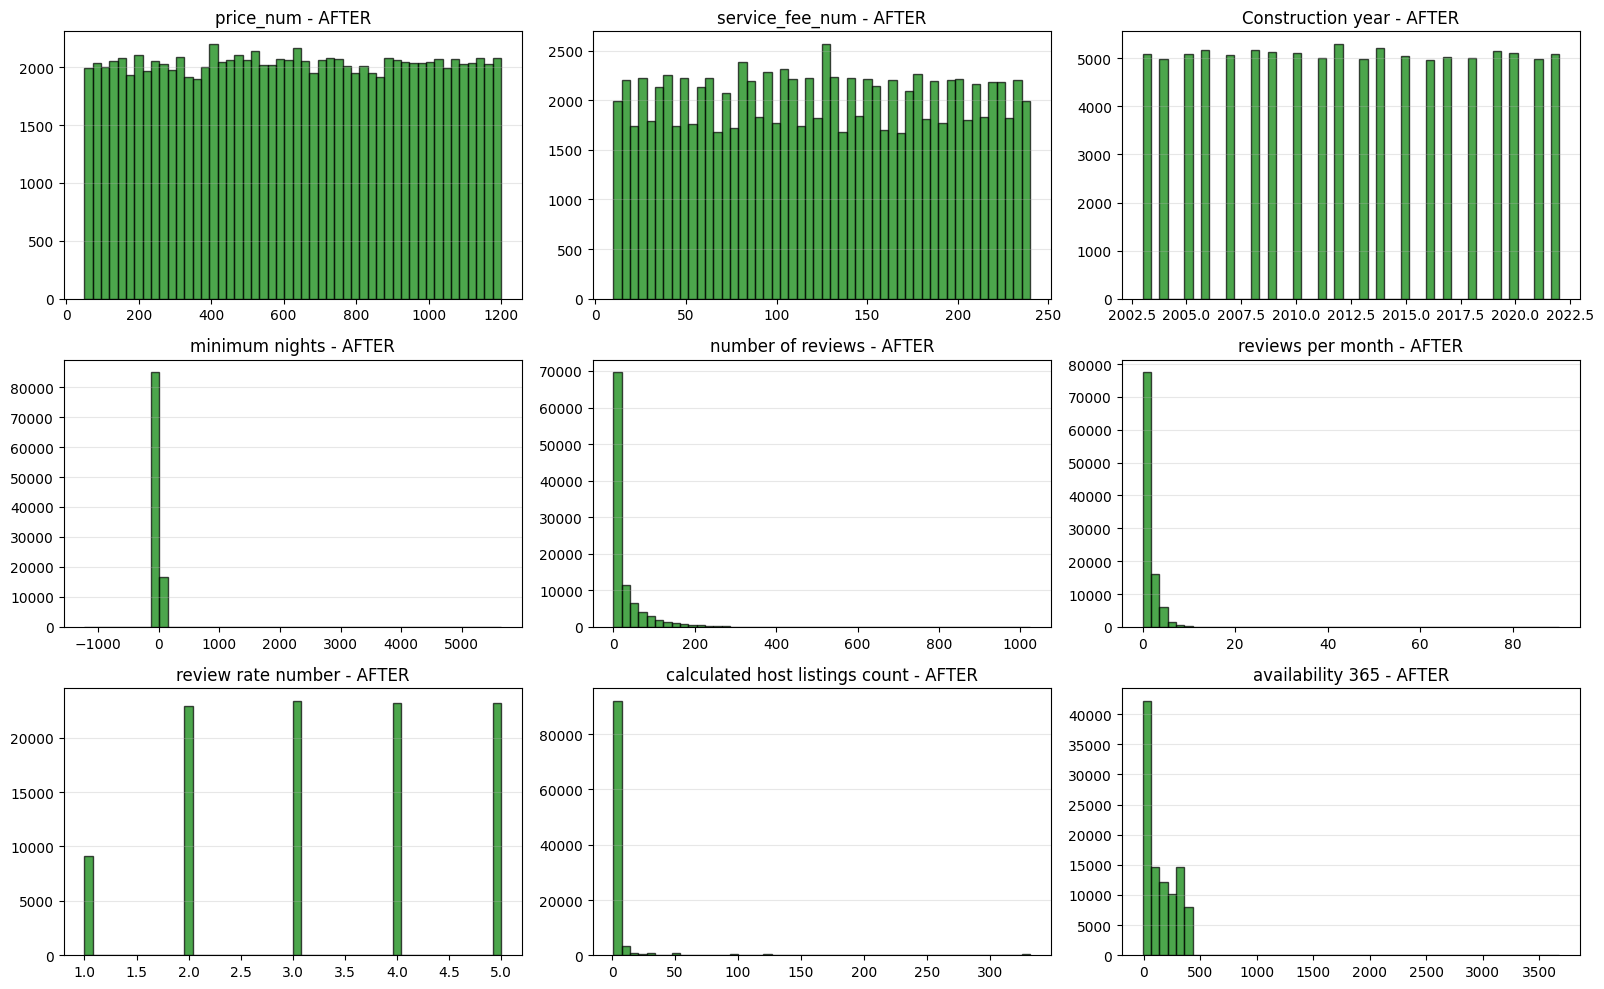

In [89]:
# Histograms after cleaning
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].hist(data_clean[col].dropna(), bins=50, color='green', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} - AFTER')
    axes[i].grid(axis='y', alpha=0.3)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

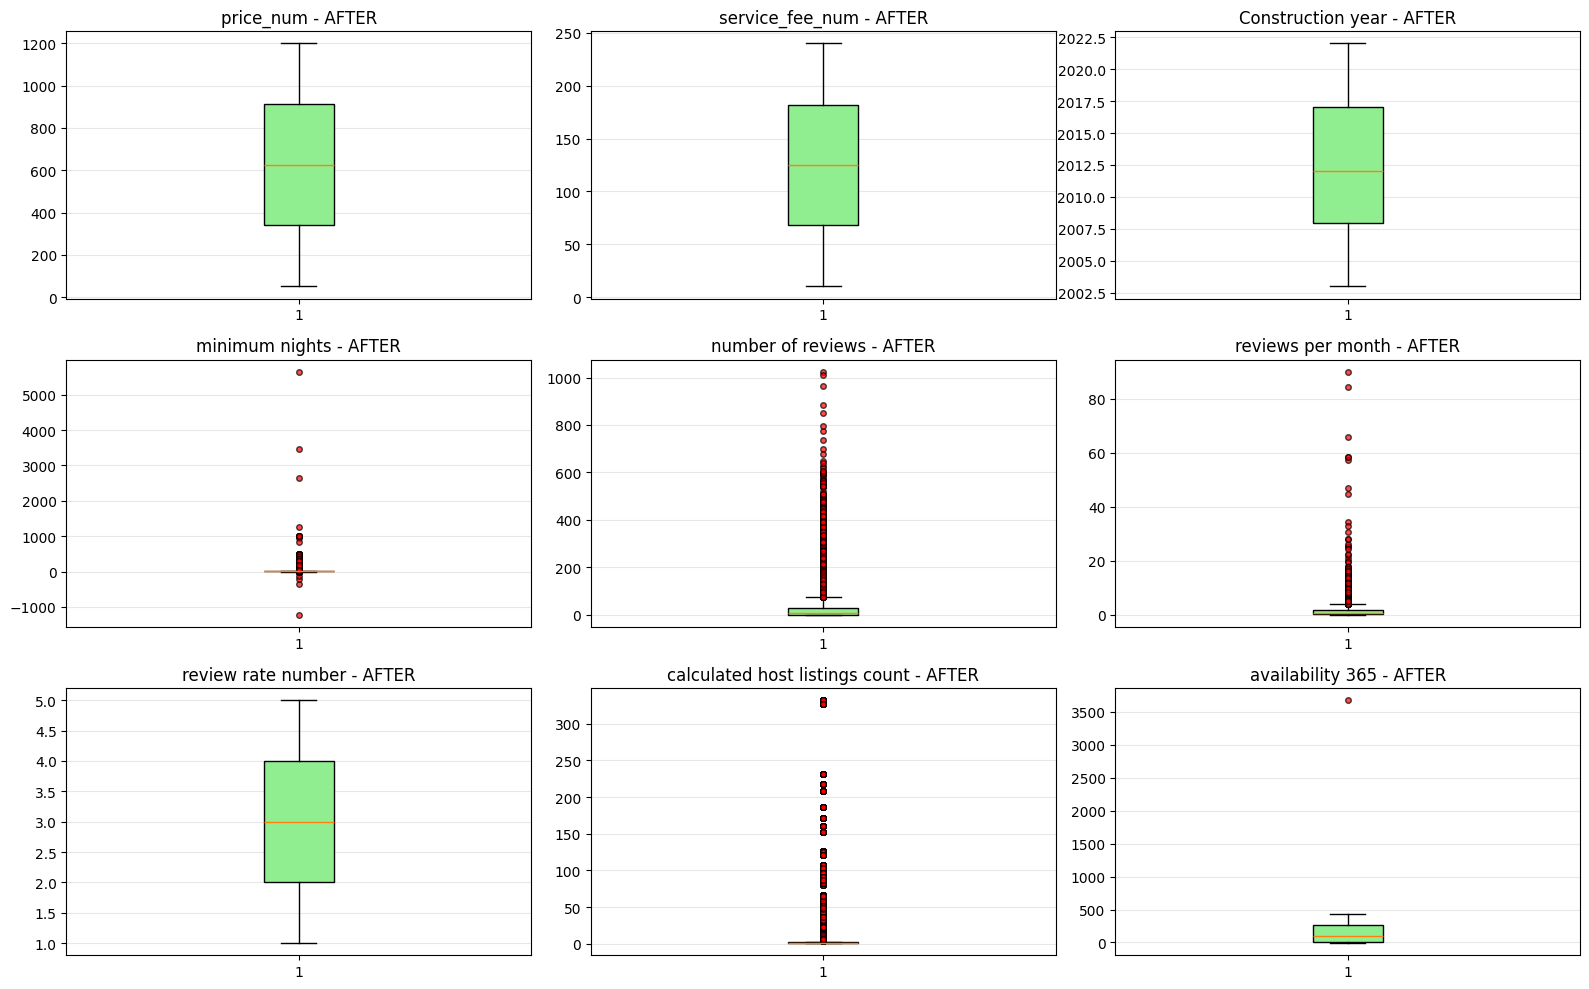

In [90]:
# Box plots after cleaning
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].boxplot(data_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.7))
    axes[i].set_title(f'{col} - AFTER')
    axes[i].grid(axis='y', alpha=0.3)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 6. Prepare Regression Data

In [91]:
target_col = 'price_num'
data_model = data_clean.copy()

leakage_cols = [col for col in ['TotalCost', 'price'] if col in data_model.columns]
feature_frame = data_model.drop(columns=[target_col] + leakage_cols, errors='ignore')

X = pd.get_dummies(feature_frame, drop_first=True)
y = data_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'X shape after encoding: {X.shape}')
print(f'X train/test: {X_train.shape} / {X_test.shape}')
print(f'Encoded features: {X.shape[1]}')

X shape after encoding: (101811, 476)
X train/test: (76358, 476) / (25453, 476)
Encoded features: 476


## 7. Correlation Matrix

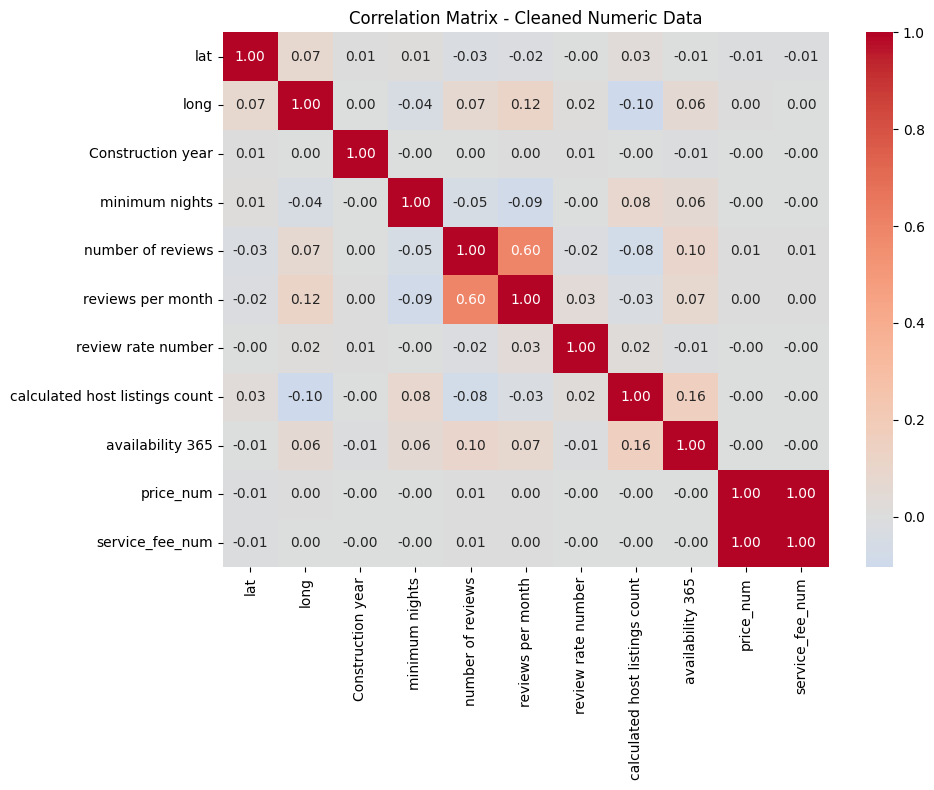

In [92]:
numeric_data = data_clean.select_dtypes(include=[np.number])
corr = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Cleaned Numeric Data')
plt.tight_layout()
plt.show()

## 8. Train Regression Model

In [104]:
linear_model = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

ridge_model = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(ridge_model, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error')
ridge_search.fit(X_train, y_train)
best_ridge_model = ridge_search.best_estimator_
predictions = best_ridge_model.predict(X_test)

print(f'Linear Regression RMSE: {linear_rmse:.2f}')
print(f'Linear Regression MAE: {linear_mae:.2f}')
print(f'Linear Regression R2: {linear_r2:.4f}')
print()
print(f'Best Ridge alpha: {ridge_search.best_params_["model__alpha"]}')
print(f'Best CV RMSE: {-ridge_search.best_score_:.2f}')

Linear Regression RMSE: 17.43
Linear Regression MAE: 2.10
Linear Regression R2: 0.9972

Best Ridge alpha: 0.1
Best CV RMSE: 16.14


## 9. Evaluate the Model

In [105]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, predictions))
ridge_mae = mean_absolute_error(y_test, predictions)
ridge_r2 = r2_score(y_test, predictions)

metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE': [linear_mae, ridge_mae],
    'RMSE': [linear_rmse, ridge_rmse],
    'R2': [linear_r2, ridge_r2],
})

print(metrics_df)

               Model       MAE       RMSE        R2
0  Linear Regression  2.100575  17.433369  0.997230
1   Ridge Regression  2.100690  17.434207  0.997229


## 10. Prediction Plots

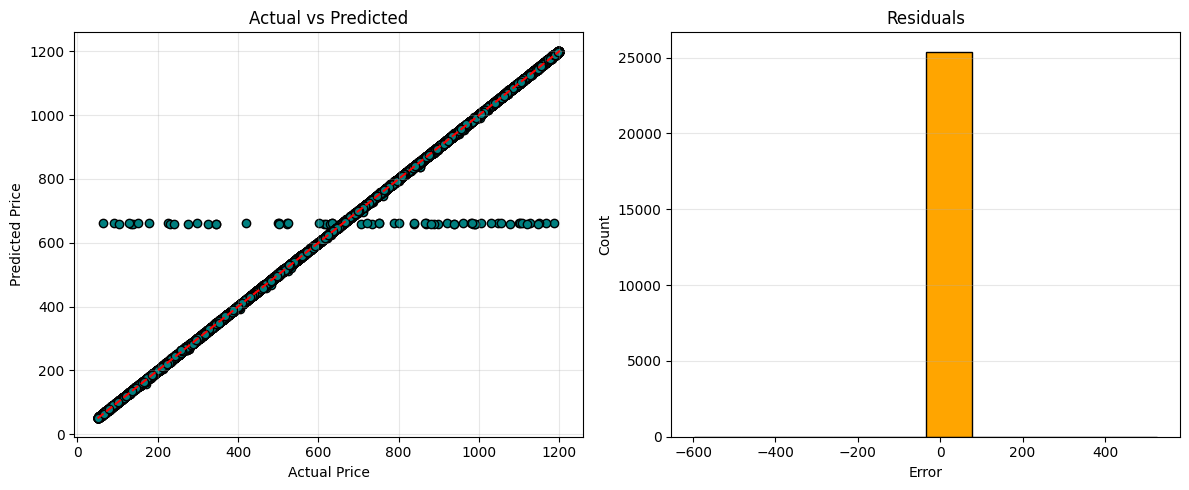

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, predictions, color='teal', edgecolor='black')
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].grid(alpha=0.3)

residuals = y_test - predictions
axes[1].hist(residuals, bins=10, color='orange', edgecolor='black')
axes[1].set_title('Residuals')
axes[1].set_xlabel('Error')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Why Ridge Regression

In [96]:
print('Ridge Regression is a simple model and the alpha value is tuned with grid search.')
print('I choose it because it is easy to explain, works well with small data, and reduces overfitting a little.')
print(f'Best alpha: {ridge_search.best_params_["model__alpha"]}')

Ridge Regression is a simple model and the alpha value is tuned with grid search.
I choose it because it is easy to explain, works well with small data, and reduces overfitting a little.
Best alpha: 0.1


## 12. Prediction Table

In [97]:
results_df = pd.DataFrame({
    'Actual price': y_test.values,
    'Predicted price': predictions,
})
results_df['Error'] = results_df['Actual price'] - results_df['Predicted price']
print(results_df)

       Actual price  Predicted price     Error
0             267.0       265.343142  1.656858
1            1113.0      1114.667932 -1.667932
2             527.0       524.967044  2.032956
3            1036.0      1034.954638  1.045362
4             404.0       405.582331 -1.582331
...             ...              ...       ...
25448         295.0       294.760340  0.239660
25449        1004.0      1004.578430 -0.578430
25450         763.0       765.104003 -2.104003
25451         956.0       955.593581  0.406419
25452         700.0       700.166116 -0.166116

[25453 rows x 3 columns]


## 13. Final Summary

In [98]:
print('Final summary:')
print(f'Cleaned rows: {len(data_clean)}')
print(f'Features used: {X.shape[1]}')
print(f'Best Ridge alpha: {ridge_search.best_params_["model__alpha"]}')
print(f'Ridge RMSE: {ridge_rmse:.2f}')
print(f'Ridge MAE: {ridge_mae:.2f}')
print(f'Ridge R2: {ridge_r2:.4f}')
print('This notebook uses a simple supervised regression setup with Ridge Regression and a small grid search.')

Final summary:
Cleaned rows: 101811
Features used: 476
Best Ridge alpha: 0.1
Ridge RMSE: 17.43
Ridge MAE: 2.10
Ridge R2: 0.9972
This notebook uses a simple supervised regression setup with Ridge Regression and a small grid search.


## 14. Feature Coefficients

In [107]:
feature_names = X_train.columns
coefficients = best_ridge_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()

print(coef_df.sort_values('abs_coef', ascending=False).head(10)[['Feature', 'Coefficient']])

               Feature  Coefficient
9      service_fee_num   351.258905
396  service fee_$237     -4.727936
397  service fee_$238     -4.679695
387  service fee_$229     -4.675303
393  service fee_$234     -4.601780
395  service fee_$236     -4.501087
386  service fee_$228     -4.481654
392  service fee_$233     -4.458857
373  service fee_$216     -4.453866
382  service fee_$224     -4.448364


In [106]:
residuals = y_test - predictions
print(f'Residual mean: {residuals.mean():.2f}')
print(f'Residual std: {residuals.std():.2f}')
print(f'Min residual: {residuals.min():.2f}')
print(f'Max residual: {residuals.max():.2f}')

Residual mean: 0.11
Residual std: 17.43
Min residual: -596.71
Max residual: 525.98


## 15. Model Choice

In [101]:
print('I chose Ridge Regression because it is simple, fast, and easy to explain.')
print('The grid search only tunes alpha, so the model stays easy to understand.')
print('This keeps the notebook close to the original cleaning and visualization logic, but changes the goal to supervised regression.')

I chose Ridge Regression because it is simple, fast, and easy to explain.
The grid search only tunes alpha, so the model stays easy to understand.
This keeps the notebook close to the original cleaning and visualization logic, but changes the goal to supervised regression.


## 16. Final Note

In [102]:
print('Notebook ready for the supervised Airbnb regression project.')

Notebook ready for the supervised Airbnb regression project.
